# The ETF share class that quietly pays you the interest-rate gap 💴
### Currency-hedged ETF carry — DXJ vs EWJ, HEWJ vs EWJ, HEDJ vs VGK, in plain English

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Investable](https://img.shields.io/badge/Tradability-Investable-2ea44f?style=flat-square)
![Unhedged_better_at_zero_carry%3F: Busted](https://img.shields.io/badge/Unhedged_better_at_zero_carry%3F-Busted-8b949e?style=flat-square)

Two funds hold the *same* Japanese stocks. One (EWJ) leaves the yen exposure alone; the other (HEWJ) *hedges* it — it sells yen forward every month. Here's the claim: because of how forward contracts are priced, that hedge doesn't just remove currency risk — it **pays you the gap between US and Japanese interest rates**. When the Fed was at ~5% and the Bank of Japan at ~0, the hedged share class was quietly collecting **~5% a year** on top of the stocks. Free carry, hidden in a share class.

Sounds too good to be true — which is exactly why we measured it.

> 📓 **Plain-language layer.** Want the HAC *t*-stats and the regressions? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from currency_hedged_etf_carry import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES = data.load_prices()
    PANEL = data.monthly_panel(PRICES, asof=data.AS_OF)
else:
    PRICES = PANEL = None
# DXJ ran an UNHEDGED dividend mandate before 2010-04-01; HEDJ an unhedged one before Jan-2012.
PAIR_START = {"DXJ/EWJ": "2010-04-01", "HEDJ/VGK": "2012-02-01"}
HIGH = "2022-07-01"
print("real tape cached:", HAVE_REAL, "| months:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fingerprint': '866b58311fd5', 'full': {'DXJ/EWJ': {'n': 195, 'start': '2010-04', 'beta': 1.05, 't_beta': 26.8, 'r2': 0.779, 'carry_bps': 21.08, 'carry_ann': 2.53, 't': 2.24, 'rate': 1.44, 'alpha_bps': 19.85, 't_alpha': 2.12, 'diff_bps': 45.99, 'fx_bps': -24.91}, 'HEWJ/EWJ': {'n': 148, 'start': '2014-03', 'beta': 0.971, 't_beta': 28.4, 'r2': 0.868, 'carry_bps': 19.92, 'carry_ann': 2.39, 't': 4.54, 'rate': 1.89, 'alpha_bps': 20.72, 't_alpha': 4.41, 'diff_bps': 47.72, 'fx_bps': -27.8}, 'HEDJ/VGK': {'n': 173, 'start': '2012-02', 'beta': 0.979, 't_beta': 17.4, 'r2': 0.68, 'carry_bps': 8.19, 'carry_ann': 0.98, 't': 0.84, 'rate': 1.11, 'alpha_bps': 8.32, 't_alpha': 0.86, 'diff_bps': 14.06, 'fx_bps': -5.87}}, 'high': {'DXJ/EWJ': {'carry_ann': 8.05, 't': 4.75, 'rate': 4.2, 'beta': 1.047, 'r2': 0.805}, 'HEWJ/EWJ': {'carry_ann': 4.83, 't': 6.01, 'rate': 4.2, 'beta': 0.98, 'r2': 0.879}, 'HEDJ/VGK': {'carry_ann': 2.63, 't': 0.9, 'rate': 1.71, 'beta': 0.941, 'r2': 0.621}}, 'zirp': {'diff_bps': 28.32, 't_diff': 0.82, 'fx_bps': -33.8, 'carry_ann': -0.66, 't_carry': -0.49, 'rate': 0.01, 'n': 69}, 'roll': {'DXJ/EWJ': (0.621, 1.83), 'HEWJ/EWJ': (0.851, 0.984), 'HEDJ/VGK': (0.227, 1.066)}, 'lags': [(3, 4.07, 4.51), (6, 4.54, 6.01), (12, 4.15, 7.67)], 'spread': {'DXJ/EWJ': (11.05, 2.74, 7.35, 4.34), 'HEWJ/EWJ': (7.84, 2.19, 4.13, 5.14), 'HEDJ/VGK': (-0.57, -0.17, 1.93, 0.66)}, 'charge_ann': 0.7, 'switch': {'DXJ/EWJ': (10.62, 13.34, 7.82, 3, 195), 'HEWJ/EWJ': (11.87, 14.21, 8.48, 3, 148), 'HEDJ/VGK': (9.02, 11.26, 9.57, 5, 173)}, 'syn': [(0.0, 0.152, 0.37), (5.0, 5.152, 12.68)], 'ers': {'DXJ': 0.48, 'EWJ': 0.5, 'HEWJ': 0.5, 'HEDJ': 0.58, 'VGK': 0.09}}


real tape cached: True | months: 258


## The answer first

| Question | Answer |
|---|---|
| Does the hedge really pocket the rate gap? | **Yes — measurably.** On the cleanest pair (HEWJ literally holds EWJ plus yen forwards) the hedged class collected **+4.8%/yr** of pure carry in 2022–2026 while the US–Japan rate gap was **+4.2%/yr** — and the two track each other almost one-for-one over time. |
| Is it free money? | **It's free *carry***: same expense ratio as the unhedged fund (Japan), one click to buy. But you pocket whatever the *observable* rate gap is — when rates converge (BOJ hiking, Fed cutting), the tap closes. |
| What about when the rate gap was zero? | **Then there's nothing to pocket** — measured carry was ≈ 0 in 2010–2015, exactly as the arithmetic says. The hedged fund still won big back then, but that was the **falling yen**, a currency bet, not carry. |
| Is this the famous "carry trade"? | Related but different. The [FX carry trade](../../364-fx-carry-trade/README.md) *chooses* currencies and bears crash risk. Here you choose nothing — the wrapper mechanically passes the rate gap through. |

## 1 · The claim

> *"A currency-hedged ETF sells the foreign currency forward. Forwards are priced so that the seller of the low-rate currency earns the interest-rate difference. So the hedged share class = the same stocks **plus** the US-minus-foreign rate gap, automatically."*

That's covered interest parity — hundred-year-old arithmetic (Keynes, 1923). If it's true in *live, fee-charging ETFs*, then `hedged − unhedged ≈ rate gap − currency move`, month after month. Rearranged: **(hedged − unhedged) + currency move = the carry**. That's a number we can measure on real funds.

## 2 · So what?

From 2022 to 2026 the Fed sat ~5 points above the Bank of Japan. If the claim holds, anyone holding a hedged Japan fund got paid ~5%/yr *just for the share class choice* — on top of the stocks, with the yen risk removed. That's enormous for a costless switch. And the flip side matters just as much: if you held the **unhedged** class, you paid that 5% in expectation. The question is whether the wrapper actually delivers the arithmetic after fees, hedge-roll slippage and real-world frictions.

## 3 · How would we even know?

Three live share-class pairs, twenty years of monthly total returns (yfinance):

1. **DXJ vs EWJ** (Japan, 2010+) — longest tape (DXJ only became a *hedged* fund in April 2010, so we start there), but DXJ holds a different, exporter-tilted basket, which adds noise.
2. **HEWJ vs EWJ** (Japan, 2014+) — the decisive pair: **HEWJ holds EWJ itself plus yen forwards**. Same stocks, same manager — the return difference *is* the hedge.
3. **HEDJ vs VGK** (Europe, 2012+) — the euro leg.

Each month we compute `(hedged − unhedged) + currency move` — the **measured carry** — and compare it to the *observable* policy-rate gap (Fed bill rate minus BOJ/ECB policy rate, hardcoded from official sources). If the claim is right, the two series should sit on top of each other.

## 4 · The teardown — let's actually look

**First, the headline check.** Measured carry vs the observable rate gap, in the era when the gap was fat (July 2022 → June 2026).

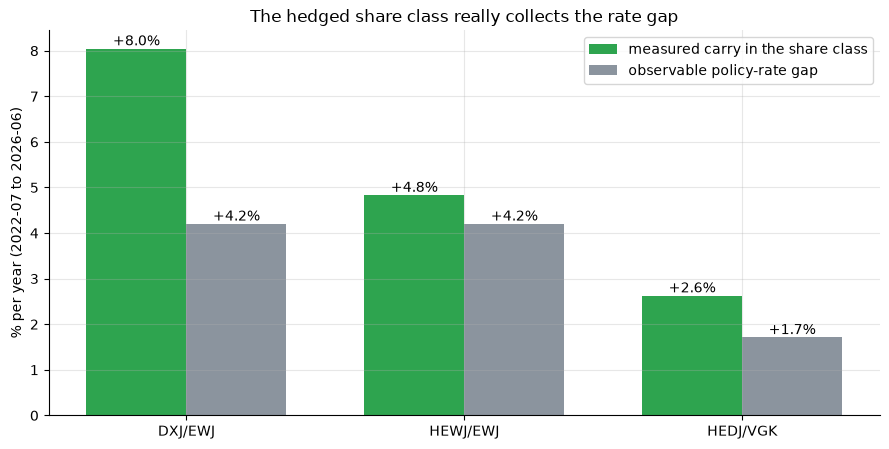

measured carry %/yr: [8.05, 4.83, 2.63]  rate gap %/yr: [4.2, 4.2, 1.71]


In [2]:
pairs = list(R['high'].keys())
if HAVE_REAL:
    vals, rates = [], []
    for p in pairs:
        hgd, unh, ccy, _ = data.PAIRS[p]
        pf = st.pair_frame(PANEL, hgd, unh, ccy, start=HIGH)
        s = st.pair_stats(pf)
        vals.append(s['carry_ann_pct']); rates.append(s['rate_diff_ann_pct'])
else:
    vals = [R['high'][p]['carry_ann'] for p in pairs]
    rates = [R['high'][p]['rate'] for p in pairs]
x = np.arange(len(pairs))
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.bar(x-.18, vals, .36, color=GREEN, label='measured carry in the share class')
ax.bar(x+.18, rates, .36, color=GREY, label='observable policy-rate gap')
for i,(v,r) in enumerate(zip(vals,rates)):
    ax.annotate(f'{v:+.1f}%',(i-.18,v),ha='center',va='bottom')
    ax.annotate(f'{r:+.1f}%',(i+.18,r),ha='center',va='bottom')
ax.set_xticks(x); ax.set_xticklabels(pairs); ax.set_ylabel('% per year (2022-07 to 2026-06)')
ax.set_title('The hedged share class really collects the rate gap')
ax.legend(); plt.tight_layout(); plt.show()
print('measured carry %/yr:', [round(v,2) for v in vals], ' rate gap %/yr:', [round(r,2) for r in rates])

On the clean pair (**HEWJ/EWJ — same stocks, only the hedge differs**) the share class collected **+4.8%/yr** against an observable gap of **+4.2%/yr**. The DXJ bar is bigger than the gap because DXJ also holds a different (exporter-heavy) basket that happened to win — basket alpha on top of carry. Europe's gap was small (+1.7%/yr), so there was little to collect.

**Does the carry *track* the gap over time?** If it's mechanical, it should follow the gap as central banks move.

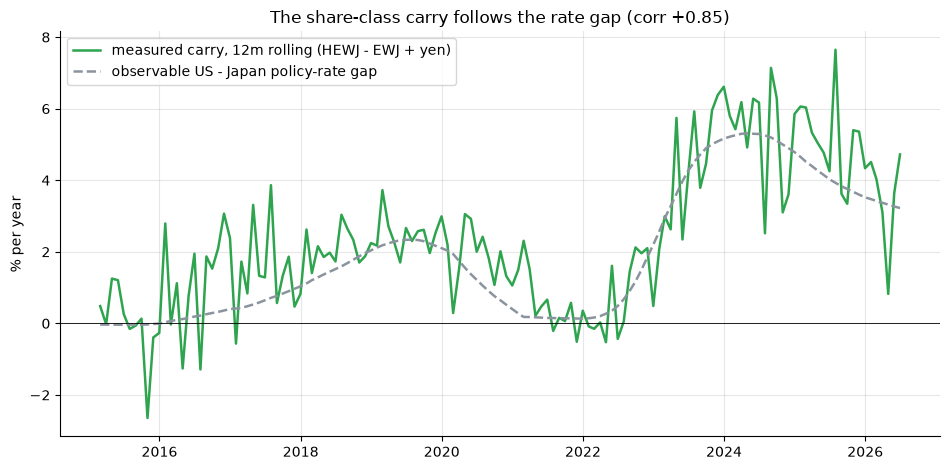

corr = +0.851   pass-through slope = +0.984


In [3]:
if HAVE_REAL:
    pf = st.pair_frame(PANEL, 'HEWJ', 'EWJ', 'JPY')
    r = st.rolling_carry_track(pf)
    fig, ax = plt.subplots(figsize=(9.6, 4.8))
    ax.plot(r['roll_carry'], color=GREEN, lw=1.8, label='measured carry, 12m rolling (HEWJ - EWJ + yen)')
    ax.plot(r['roll_diff'], color=GREY, lw=1.8, ls='--', label='observable US - Japan policy-rate gap')
    ax.axhline(0, c='k', lw=.6)
    ax.set_ylabel('% per year'); ax.set_title(f'The share-class carry follows the rate gap (corr {r["corr"]:+.2f})')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'corr = {r["corr"]:+.3f}   pass-through slope = {r["slope"]:+.3f}')
else:
    c, sl = R['roll']['HEWJ/EWJ']
    print(f'(no cache) frozen numbers: corr = {c:+.3f}, pass-through slope = {sl:+.3f}')

The green line (what the share class actually paid) hugs the grey dashes (the official rate gap): correlation **+0.85**, pass-through slope **0.98** — one-for-one. Watch the right edge: as the BOJ hikes and the Fed cuts, **the tap is already closing**. This is not a permanent freebie; it's the *current, observable* gap, delivered mechanically.

**And when the gap was zero?** 2010–2015: US and Japanese rates were both stuck at ~0.

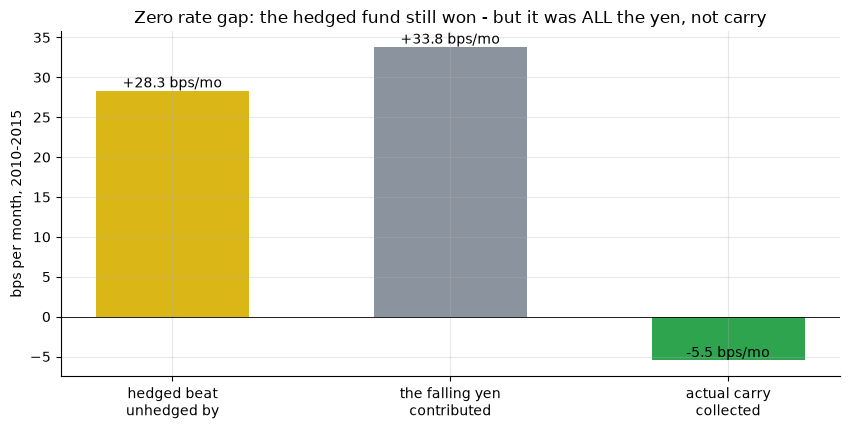

hedged-unhedged +28.3 bps/mo | yen move -33.8 bps/mo | carry -5.5 bps/mo


In [4]:
if HAVE_REAL:
    pf = st.pair_frame(PANEL, 'DXJ', 'EWJ', 'JPY', start='2010-04-01', end='2015-12-31')
    s = st.pair_stats(pf)
    dif, fx, car = s['diff_bps'], s['fx_bps'], s['carry_bps']
else:
    z = R['zirp']; dif, fx, car = z['diff_bps'], z['fx_bps'], z['carry_ann']/12*100
fig, ax = plt.subplots(figsize=(8.6, 4.4))
bars = ['hedged beat\nunhedged by', 'the falling yen\ncontributed', 'actual carry\ncollected']
vals = [dif, -fx, car]
ax.bar(bars, vals, color=[AMBER, GREY, GREEN], width=.55)
for i,v in enumerate(vals): ax.annotate(f'{v:+.1f} bps/mo',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.6); ax.set_ylabel('bps per month, 2010-2015')
ax.set_title('Zero rate gap: the hedged fund still won - but it was ALL the yen, not carry')
plt.tight_layout(); plt.show()
print(f'hedged-unhedged {dif:+.1f} bps/mo | yen move {fx:+.1f} bps/mo | carry {car:+.1f} bps/mo')

> 🔬 **For the quants:** the 2010–2015 carry component is **-0.66%/yr at HAC t = -0.49** — statistically nothing, exactly what the arithmetic demands when the gap is zero.

The hedged fund still beat the unhedged one back then — but the green bar shows the carry was **zero**. The entire win was the yen collapsing under Abenomics. Lesson: **when the rate gap is thin, hedged-vs-unhedged is purely a currency opinion.** The carry story only pays when the gap is fat — and you can *see* the gap in advance, it's the policy rates.

## 5 · The verdict

- **Signal — Real.** The hedge is a genuine full currency short (β ≈ 1) and the carry it pockets matched the observable rate gap one-for-one — **+4.8%/yr** in 2022–2026 on the same-basket pair, with rock-solid statistics (see the quants notebook).
- **Tradability — Investable.** Same expense ratio as the unhedged class (Japan), one click, billions of capacity, and the "signal" is a public policy rate — 3–5 switches in a decade. Europe's wrapper charges ~0.5%/yr extra, eating half its (smaller) gap.
- **"Unhedged was better when carry was ~zero"? — Busted.** With no gap there was no carry (as the math says) — the hedged class won 2010–2015 anyway, purely on the falling yen. At thin gaps the choice is an FX bet, not a carry harvest.

## 6 · Going further 🚪

- **The tap closes.** By mid-2026 BOJ hikes and Fed cuts had shrunk the gap from ~5.3% to ~3.3%/yr. The share class will keep delivering *whatever the gap is* — including ~0.
- **The hedge pays slightly MORE than the policy gap** (~0.5%/yr on HEWJ). That's the famous negative **yen cross-currency basis** — dollar lenders get a bonus for lending dollars forward. See the quants notebook.
- **Cousins on the desk.** The [FX carry trade](../../364-fx-carry-trade/README.md) earns carry by *choosing* risky currencies (and eats the crashes); this study's carry is chosen for you by the wrapper. Compare also [611-mreit-carry](../../611-mreit-carry/README.md) and [612-em-debt-carry](../../612-em-debt-carry/README.md) — packaged carry, messier vehicles.

*Think the hedged class is always better? Re-read the 2010–2015 chart — then look up what happened to hedged-Japan holders in months the yen spiked 5%.*